# Quantum Computing Lab

## Assignment 6

### Mrudula A Mahindrakar, EE25S011

In [29]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer.primitives import EstimatorV2

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Variational Quantum Eigensolver (VEQ)

## Constructing the Hamiltonian

Consider the two–qubit Hamiltonian

$H = Z_0Z_1 + X_0 + X_1$

1. Construct the Hamiltonian in Qiskit using the SparsePauliOp class.
2. Print the matrix representation of the Hamiltonian.
3. Compute the eigenvalues of the Hamiltonian using classical diagonalization.
4. Identify the exact ground state energy

In [30]:
# H = Z_0Z_1 + X_0 + X_1
hamiltonian = SparsePauliOp(['ZZ', 'XI', 'IX'], coeffs=[1, 1, 1])
print(hamiltonian)

SparsePauliOp(['ZZ', 'XI', 'IX'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])


In [31]:
hamiltonian_matrix = hamiltonian.to_matrix()
print(hamiltonian_matrix)

[[ 1.+0.j  1.+0.j  1.+0.j  0.+0.j]
 [ 1.+0.j -1.+0.j  0.+0.j  1.+0.j]
 [ 1.+0.j  0.+0.j -1.+0.j  1.+0.j]
 [ 0.+0.j  1.+0.j  1.+0.j  1.+0.j]]


In [32]:
eigenvalues = np.linalg.eigvalsh(hamiltonian_matrix)
ground_state_energy = np.min(eigenvalues)

print("Eigenvalues of H:")
print(eigenvalues)
print(f"\nGround State Energy: {ground_state_energy}")

Eigenvalues of H:
[-2.23606798 -1.          1.          2.23606798]

Ground State Energy: -2.236067977499789


## Parameterized Ansatz Circuit
1. Construct a parameterized ansatz circuit with the following structure:
  * Apply Ry(θ1) on qubit 0
  * Apply Ry(θ2) on qubit 1
  * Apply a CNOT gate between qubit 0 and qubit 1
2. Draw the circuit using Qiskit visualization tools.
3. Simulate the circuit using the statevector simulator.
4. Print the output statevector for different parameter values.

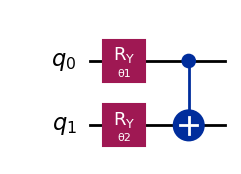

In [33]:
theta_1 = Parameter('θ1')
theta_2 = Parameter('θ2')

ansatz_circuit = QuantumCircuit(2)
ansatz_circuit.ry(theta_1, 0)
ansatz_circuit.ry(theta_2, 1)
ansatz_circuit.cx(0, 1)

ansatz_circuit.draw(output='mpl')

In [34]:
simulator = AerSimulator()

# Case 1: theta_1 = 0, theta_2 = 0
parameters_case1 = {theta_1: 0, theta_2: 0}
bound_circuit_case1 = ansatz_circuit.assign_parameters(parameters_case1)
bound_circuit_case1.save_statevector()

job_case1 = simulator.run(bound_circuit_case1)
result_case1 = job_case1.result()
statevector_case1 = result_case1.get_statevector(bound_circuit_case1)

print("Output Statevector for (θ1=0, θ2=0):")
print(statevector_case1)
print("\n")

# Case 2: theta_1 = pi/2, theta_2 = pi/2
parameters_case2 = {theta_1: np.pi/2, theta_2: np.pi/2}
bound_circuit_case2 = ansatz_circuit.assign_parameters(parameters_case2)
bound_circuit_case2.save_statevector()

job_case2 = simulator.run(bound_circuit_case2)
result_case2 = job_case2.result()
statevector_case2 = result_case2.get_statevector(bound_circuit_case2)

print("Output Statevector for (θ1=π/2, θ2=π/2):")
print(statevector_case2)

Output Statevector for (θ1=0, θ2=0):
Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


Output Statevector for (θ1=π/2, θ2=π/2):
Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))


## Expectation Value Estimation
1. Using Qiskit primitives such as Estimator, compute the expectation value
$E(θ) = \langle ψ(θ)\vert H \vert ψ(θ)\rangle.$
2. Plot the energy landscape as a function of θ1 and θ2.
3. Fix θ2 and vary θ1 over the interval [0, 2π] and plot the energy E(θ1).
4. Repeat the procedure by fixing θ1 and varying θ2.
5. Comment on the shape of the energy landscape.

In [35]:
def compute_expectation_value(theta1_val, theta2_val, ansatz_circuit, hamiltonian):

    estimator = EstimatorV2()

    parameters_map = {theta_1: theta1_val, theta_2: theta2_val}
    bound_circuit = ansatz_circuit.assign_parameters(parameters_map)

    job = estimator.run([(bound_circuit, hamiltonian)])
    result = job.result()

    return result._pub_results[0].data.evs.item()

In [36]:
import numpy as np

n_points = 50 
theta_range = np.linspace(0, 2 * np.pi, n_points)

theta1_range = theta_range
theta2_range = theta_range

THETA1, THETA2 = np.meshgrid(theta1_range, theta2_range)

energy_landscape_data = np.zeros((n_points, n_points))

for i in range(n_points):
    for j in range(n_points):
        theta1_val = THETA1[i, j]
        theta2_val = THETA2[i, j]
        energy = compute_expectation_value(theta1_val, theta2_val, ansatz_circuit, hamiltonian)
        energy_landscape_data[i, j] = energy

print(f"Shape of energy_landscape_data: {energy_landscape_data.shape}")

Shape of energy_landscape_data: (50, 50)


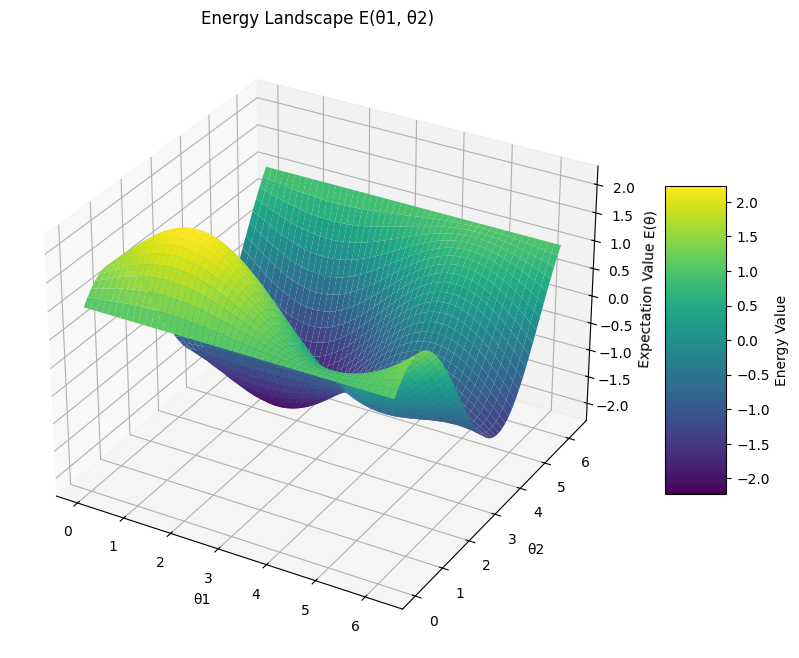

In [37]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(THETA1, THETA2, energy_landscape_data, cmap='viridis')

ax.set_xlabel('θ1')
ax.set_ylabel('θ2')
ax.set_zlabel('Expectation Value E(θ)')
ax.set_title('Energy Landscape E(θ1, θ2)')
fig.colorbar(surf, shrink=0.5, aspect=5, label='Energy Value')
plt.show()

The global minimum of the energy landscape corresponds to the ground state energy of the Hamiltonian.

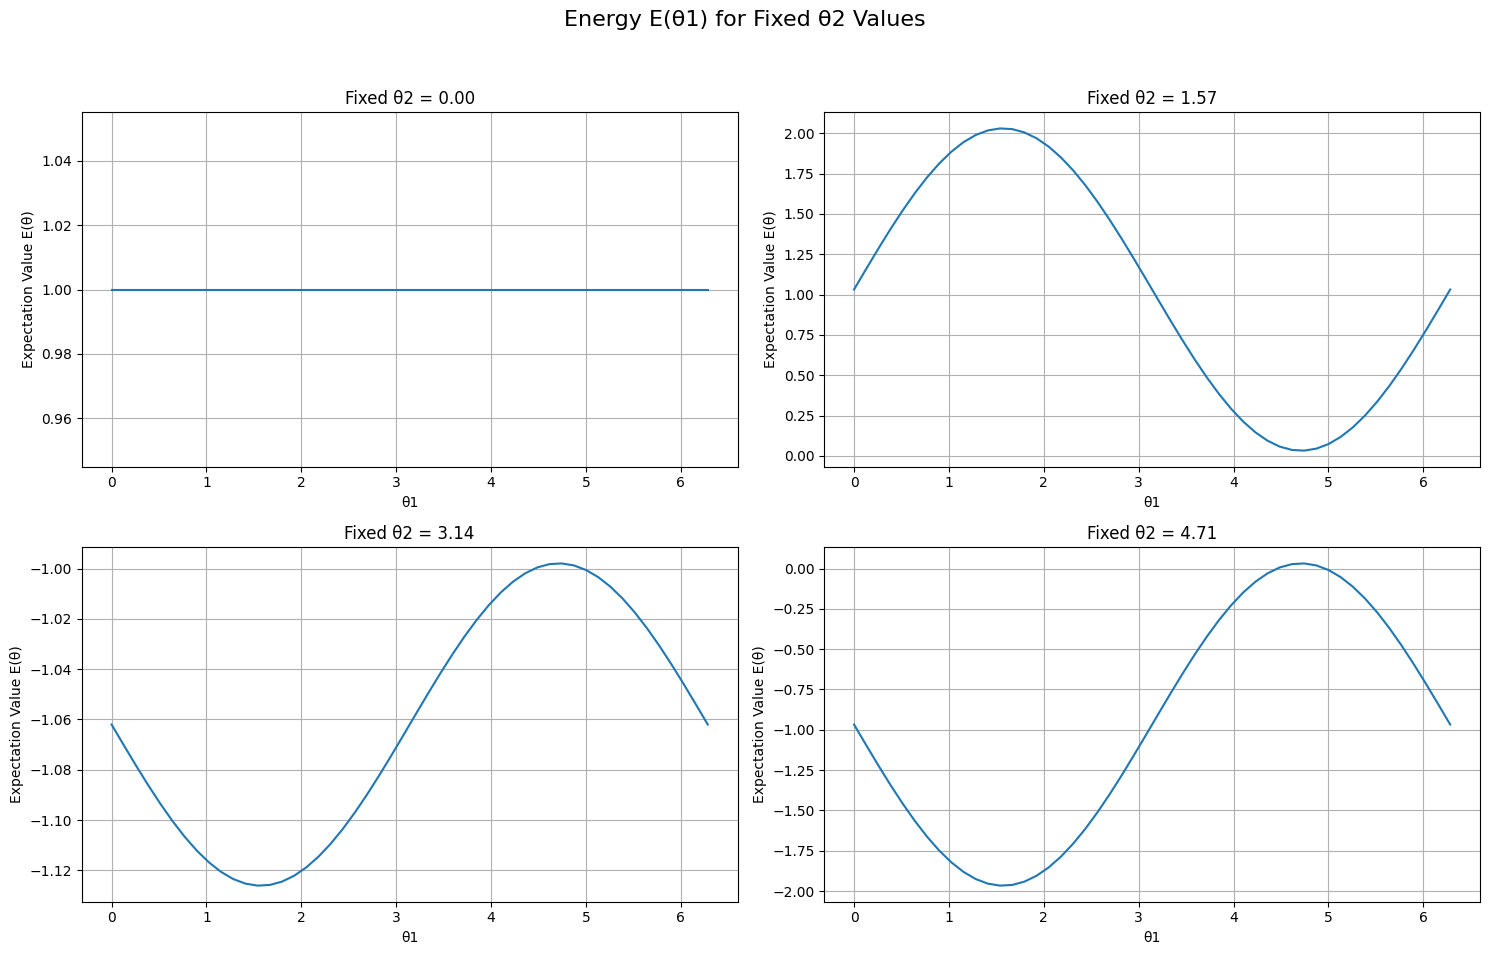

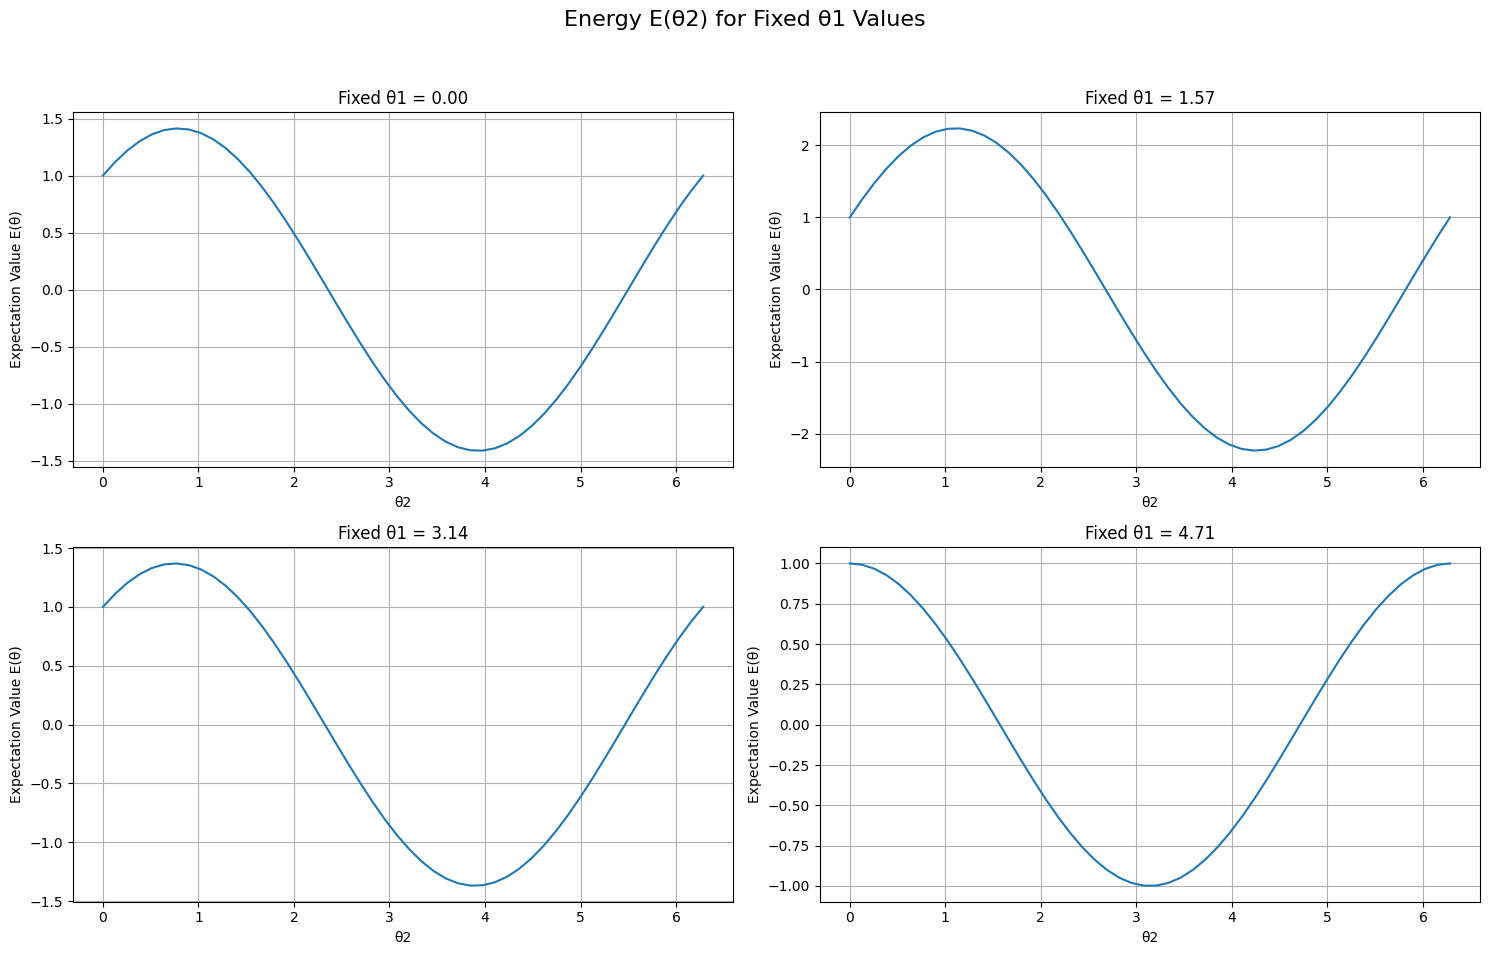

In [38]:
fixed_theta2_values = [0, np.pi/2, np.pi, 3*np.pi/2]

plt.figure(figsize=(15, 10))
plt.suptitle('Energy E(θ1) for Fixed θ2 Values', fontsize=16)

for i, fixed_val in enumerate(fixed_theta2_values):
    idx = np.argmin(np.abs(theta2_range - fixed_val))

    energy_slice_theta1 = energy_landscape_data[idx, :]

    plt.subplot(2, 2, i + 1)
    plt.plot(theta1_range, energy_slice_theta1)
    plt.xlabel('θ1')
    plt.ylabel('Expectation Value E(θ)')
    plt.title(f'Fixed θ2 = {fixed_val:.2f}')
    plt.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


fixed_theta1_values = [0, np.pi/2, np.pi, 3*np.pi/2]

plt.figure(figsize=(15, 10))
plt.suptitle('Energy E(θ2) for Fixed θ1 Values', fontsize=16)

for i, fixed_val in enumerate(fixed_theta1_values):
    idx = np.argmin(np.abs(theta1_range - fixed_val))

    energy_slice_theta2 = energy_landscape_data[:, idx]

    plt.subplot(2, 2, i + 1)
    plt.plot(theta2_range, energy_slice_theta2)
    plt.xlabel('θ2')
    plt.ylabel('Expectation Value E(θ)')
    plt.title(f'Fixed θ1 = {fixed_val:.2f}')
    plt.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## VQE Optimization
1. Implement the VQE algorithm using the ansatz defined above.
2. Use a classical optimizer such as COBYLA, SLSQP, or SPSA.
3. Plot the energy value as a function of optimization iterations.
4. Report the optimal parameters and the minimum energy obtained.
5. Compare the obtained result with the exact ground state energy.

In [39]:
estimator_vqe = EstimatorV2()

cobyla_optimizer = COBYLA(maxiter=100)

vqe_solver = VQE(estimator_vqe, ansatz_circuit, cobyla_optimizer)

In [40]:
vqe_energies = []
vqe_parameters = []

def store_vqe_data(eval_count, parameters, mean, std):
    vqe_energies.append(mean)
    vqe_parameters.append(parameters)
    print(f'Iteration {eval_count}: Energy = {mean:.4f}')

In [41]:
estimator_vqe = EstimatorV2()
cobyla_optimizer = COBYLA(maxiter=100)

initial_point_for_vqe = np.random.rand(ansatz_circuit.num_parameters) * 2 * np.pi
vqe_solver = VQE(estimator_vqe, ansatz_circuit, cobyla_optimizer, initial_point=initial_point_for_vqe, callback=store_vqe_data)

In [42]:
vqe_energies = []
vqe_parameters = []

vqe_result = vqe_solver.compute_minimum_eigenvalue(hamiltonian)

Iteration 1: Energy = -0.9466
Iteration 2: Energy = -0.9580
Iteration 3: Energy = -1.8621
Iteration 4: Energy = -1.0448
Iteration 5: Energy = -1.6564
Iteration 6: Energy = -1.6798
Iteration 7: Energy = -1.9920
Iteration 8: Energy = -2.2211
Iteration 9: Energy = -2.1443
Iteration 10: Energy = -2.1419
Iteration 11: Energy = -2.2039
Iteration 12: Energy = -2.2340
Iteration 13: Energy = -2.2169
Iteration 14: Energy = -2.2346
Iteration 15: Energy = -2.2357
Iteration 16: Energy = -2.2356
Iteration 17: Energy = -2.2350
Iteration 18: Energy = -2.2358
Iteration 19: Energy = -2.2357
Iteration 20: Energy = -2.2355
Iteration 21: Energy = -2.2360
Iteration 22: Energy = -2.2360
Iteration 23: Energy = -2.2360
Iteration 24: Energy = -2.2360
Iteration 25: Energy = -2.2360
Iteration 26: Energy = -2.2360
Iteration 27: Energy = -2.2361
Iteration 28: Energy = -2.2361
Iteration 29: Energy = -2.2361
Iteration 30: Energy = -2.2361
Iteration 31: Energy = -2.2361
Iteration 32: Energy = -2.2361
Iteration 33: Ene

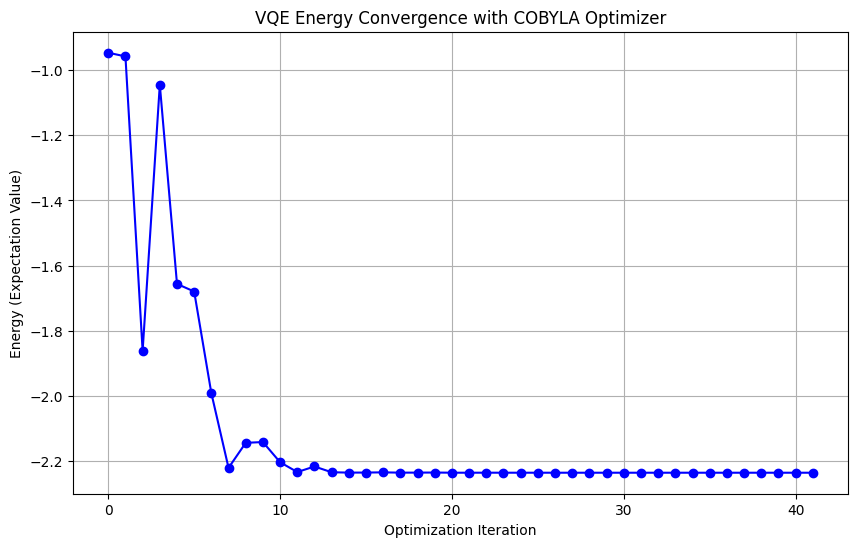

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(vqe_energies)), vqe_energies, marker='o', linestyle='-', color='blue')
plt.xlabel('Optimization Iteration')
plt.ylabel('Energy (Expectation Value)')
plt.title('VQE Energy Convergence with COBYLA Optimizer')
plt.grid(True)
plt.show()

In [44]:
vqe_min_energy = vqe_result.eigenvalue.real
vqe_optimal_parameters = vqe_result.optimal_parameters

print(f"QE Optimization Results: ")
print(f"Optimal parameters (θ1, θ2): {vqe_optimal_parameters}")
print(f"Minimum energy found by VQE: {vqe_min_energy:.6f}")
print(f"Exact Ground State Energy (classical): {ground_state_energy:.6f}")
print(f"Difference: {abs(vqe_min_energy - ground_state_energy):.6f}")

QE Optimization Results: 
Optimal parameters (θ1, θ2): {Parameter(θ1): np.float64(1.5707085439695734), Parameter(θ2): np.float64(4.2487622765168345)}
Minimum energy found by VQE: -2.236068
Exact Ground State Energy (classical): -2.236068
Difference: 0.000000


## Effect of Ansatz Depth
1. Modify the ansatz by adding an additional layer of rotation gates and entangling
gates.
2. Run the VQE algorithm with the deeper ansatz.
3. Compare the convergence behavior with the previous ansatz.
4. Plot both energy convergence curves on the same graph.

In [45]:
theta_3 = Parameter('θ3')
theta_4 = Parameter('θ4')

deeper_ansatz_circuit = QuantumCircuit(2)

# Layer 1 - original ansatz circuit
deeper_ansatz_circuit.ry(theta_1, 0)
deeper_ansatz_circuit.ry(theta_2, 1)
deeper_ansatz_circuit.cx(0, 1)

# Layer 2 - additional layer of rotation and engangling gates
deeper_ansatz_circuit.ry(theta_3, 0)
deeper_ansatz_circuit.ry(theta_4, 1)
deeper_ansatz_circuit.cx(0, 1)

deeper_ansatz_circuit.draw(output='mpl', fold=-1, idle_wires=False)
print("Deeper ansatz circuit constructed successfully.")

Deeper ansatz circuit constructed successfully.


In [46]:
deeper_vqe_energies = []
deeper_vqe_parameters = []

def store_deeper_vqe_data(eval_count, parameters, mean, std):
    deeper_vqe_energies.append(mean)
    deeper_vqe_parameters.append(parameters)
    print(f'Deeper VQE Iteration {eval_count}: Energy = {mean:.4f}')

In [47]:
estimator_vqe_deeper = EstimatorV2()
cobyla_optimizer_deeper = COBYLA(maxiter=100)

initial_point_for_deeper_vqe = np.random.rand(deeper_ansatz_circuit.num_parameters) * 2 * np.pi

deeper_vqe_solver = VQE(estimator_vqe_deeper, deeper_ansatz_circuit, cobyla_optimizer_deeper,
                      initial_point=initial_point_for_deeper_vqe, callback=store_deeper_vqe_data)

deeper_vqe_result = deeper_vqe_solver.compute_minimum_eigenvalue(hamiltonian)

Deeper VQE Iteration 1: Energy = -0.5540
Deeper VQE Iteration 2: Energy = -1.2819
Deeper VQE Iteration 3: Energy = -2.0129
Deeper VQE Iteration 4: Energy = -2.0486
Deeper VQE Iteration 5: Energy = -1.3368
Deeper VQE Iteration 6: Energy = -0.2123
Deeper VQE Iteration 7: Energy = -2.1471
Deeper VQE Iteration 8: Energy = -2.2315
Deeper VQE Iteration 9: Energy = -2.1342
Deeper VQE Iteration 10: Energy = -2.2191
Deeper VQE Iteration 11: Energy = -1.8118
Deeper VQE Iteration 12: Energy = -2.2101
Deeper VQE Iteration 13: Energy = -2.2071
Deeper VQE Iteration 14: Energy = -2.2204
Deeper VQE Iteration 15: Energy = -2.2197
Deeper VQE Iteration 16: Energy = -2.2311
Deeper VQE Iteration 17: Energy = -2.2352
Deeper VQE Iteration 18: Energy = -2.2353
Deeper VQE Iteration 19: Energy = -2.2353
Deeper VQE Iteration 20: Energy = -2.2337
Deeper VQE Iteration 21: Energy = -2.2355
Deeper VQE Iteration 22: Energy = -2.2346
Deeper VQE Iteration 23: Energy = -2.2350
Deeper VQE Iteration 24: Energy = -2.2348
D

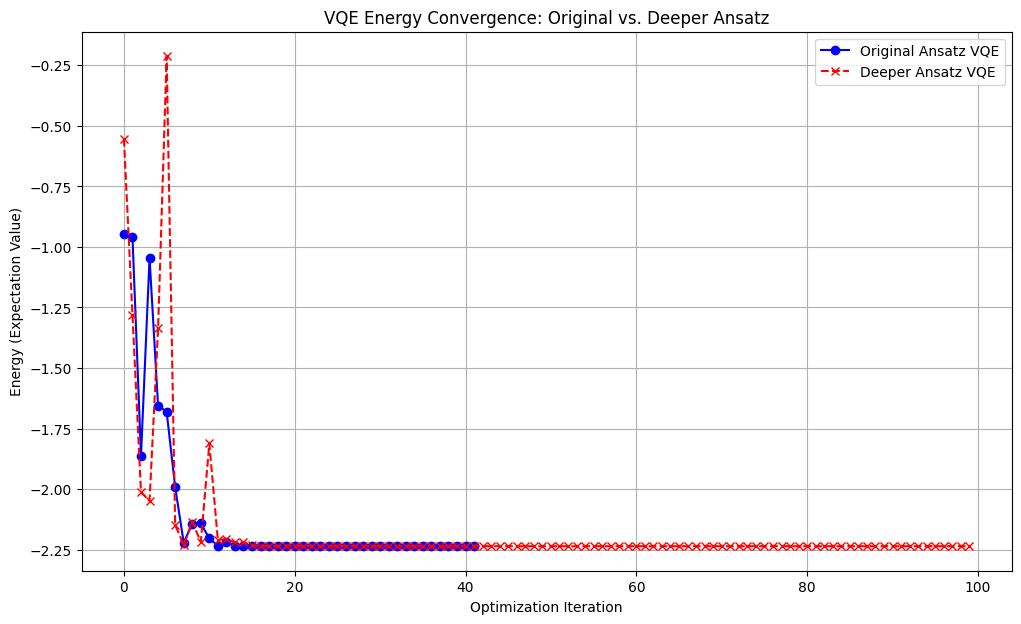

In [48]:
plt.figure(figsize=(12, 7))

plt.plot(range(len(vqe_energies)), vqe_energies, marker='o', linestyle='-', color='blue', label='Original Ansatz VQE')
plt.plot(range(len(deeper_vqe_energies)), deeper_vqe_energies, marker='x', linestyle='--', color='red', label='Deeper Ansatz VQE')

plt.xlabel('Optimization Iteration')
plt.ylabel('Energy (Expectation Value)')
plt.title('VQE Energy Convergence: Original vs. Deeper Ansatz')
plt.grid(True)
plt.legend()
plt.show()

From the convergence plot, we observe that the deeper ansatz converges more smoothly and can reach energy values closer to the exact ground state energy. 
This demonstrates that increasing circuit depth can enhance VQE performance, although it may also increase computational cost.

In [49]:
deeper_vqe_min_energy = deeper_vqe_result.eigenvalue.real

deeper_vqe_optimal_parameters = deeper_vqe_result.optimal_parameters

print(f"\n--- Deeper Ansatz VQE Optimization Results ---")
print(f"Optimal parameters (θ1, θ2, θ3, θ4): {deeper_vqe_optimal_parameters}")
print(f"Minimum energy found by Deeper VQE: {deeper_vqe_min_energy:.6f}")

print(f"Exact Ground State Energy (classical): {ground_state_energy:.6f}")
print(f"Difference: {abs(deeper_vqe_min_energy - ground_state_energy):.6f}")


--- Deeper Ansatz VQE Optimization Results ---
Optimal parameters (θ1, θ2, θ3, θ4): {Parameter(θ1): np.float64(3.1412173206451377), Parameter(θ2): np.float64(2.4756456525699435), Parameter(θ3): np.float64(4.712828057573825), Parameter(θ4): np.float64(3.5828615975695426)}
Minimum energy found by Deeper VQE: -2.236068
Exact Ground State Energy (classical): -2.236068
Difference: 0.000000


## Measurement Statistics
1. Run the optimized VQE circuit with different numbers of shots (for example: 512,
1024, 4096).
2. Study how the estimated energy changes with the number of shots.
3. Plot the estimated energy versus number of shots.

In [50]:
def run_vqe_with_shots(shots):
    estimator_with_shots = EstimatorV2(options={'run_options': {'shots': shots}})
    cobyla_optimizer = COBYLA(maxiter=100)

    initial_point_for_vqe = np.random.rand(ansatz_circuit.num_parameters) * 2 * np.pi
    vqe_solver = VQE(estimator_with_shots, ansatz_circuit, cobyla_optimizer, initial_point=initial_point_for_vqe)
    
    vqe_result = vqe_solver.compute_minimum_eigenvalue(hamiltonian)
    min_energy = vqe_result.eigenvalue.real
    
    return min_energy

In [51]:
shots_list = [512, 1024, 2048, 4096, 8192]

estimated_energies = []

for shots in shots_list:
    print(f"\nRunning VQE with {shots} shots...")
    min_energy = run_vqe_with_shots(shots)
    estimated_energies.append(min_energy)
    print(f"Minimum energy for {shots} shots: {min_energy:.6f}")

print(f"Shot Counts: {shots_list}")
print(f"Estimated Energies \n: {estimated_energies}")


Running VQE with 512 shots...
Minimum energy for 512 shots: -2.236068

Running VQE with 1024 shots...
Minimum energy for 1024 shots: -2.236068

Running VQE with 2048 shots...
Minimum energy for 2048 shots: -2.236068

Running VQE with 4096 shots...
Minimum energy for 4096 shots: -2.179484

Running VQE with 8192 shots...
Minimum energy for 8192 shots: -2.236068
Shot Counts: [512, 1024, 2048, 4096, 8192]
Estimated Energies 
: [np.float64(-2.236067974558574), np.float64(-2.236067961670578), np.float64(-2.2360679656476634), np.float64(-2.179483661965601), np.float64(-2.2360679635694884)]


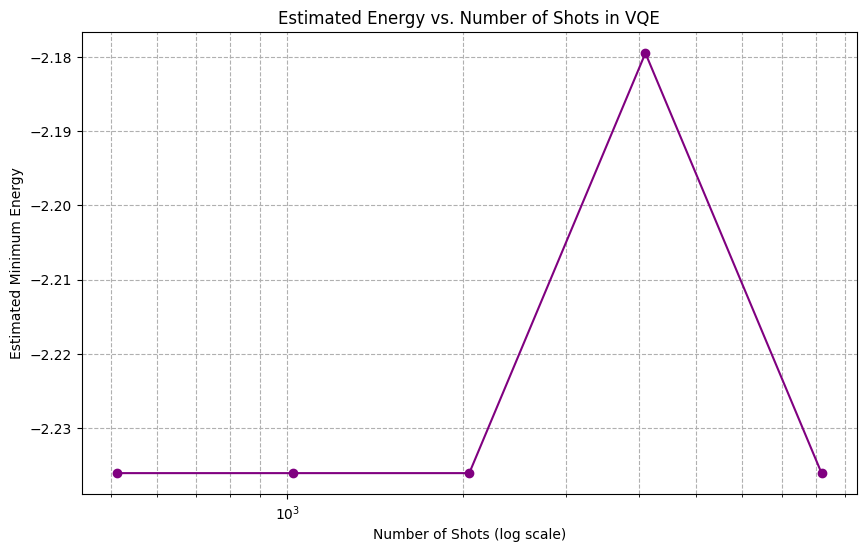

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(shots_list, estimated_energies, marker='o', linestyle='-', color='purple')
plt.xscale('log')

plt.xlabel('Number of Shots (log scale)')
plt.ylabel('Estimated Minimum Energy')
plt.title('Estimated Energy vs. Number of Shots in VQE')
plt.grid(True, which='both', ls='--')
plt.show()